<a href="https://colab.research.google.com/github/paidasahithi26/NLP_Assignments02/blob/main/Sahithi_Paida_(computational%20methods)_Assignment_2_final_(1)_2_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [4]:
# Write your code here

import pandas as pd
import re
import spacy
from collections import Counter
from nltk.corpus import stopwords
import nltk

# Ensure you have the necessary NLP tools
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))

# 1. Load your RAW file
try:
    df = pd.read_csv("semantic_scholar_data (1).csv")
except FileNotFoundError:
    print("Error: Please upload 'semantic_scholar_data (1).csv' to the Colab folder.")

# 2. Quick Cleaning Function
def simple_clean(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

# Apply cleaning to get the first 100 abstracts
reviews_raw = df['Abstract'].head(100).astype(str).tolist()
reviews_cleaned = [simple_clean(r) for r in reviews_raw]

# 3. Question 1 (1) & (2): N-grams (N=2, N=3) and Probabilities from Scratch
def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

all_unigrams = []
all_bigrams = []
all_trigrams = []

for doc in reviews_cleaned:
    tokens = doc.split()
    all_unigrams.extend(tokens)
    all_bigrams.extend(get_ngrams(tokens, 2))
    all_trigrams.extend(get_ngrams(tokens, 3))

# Frequency Counts (N=2 and N=3)
uni_counts = Counter(all_unigrams)
bi_counts = Counter(all_bigrams)
tri_counts = Counter(all_trigrams)

# Bigram Probabilities: count(w1 w2) / count(w1)
bigram_probs = {bg: count / uni_counts[bg[0]] for bg, count in bi_counts.items() if bg[0] in uni_counts}

# 4. Question 1 (3): Noun Phrases Table
all_noun_phrases = []
doc_np_freqs = []

for doc_text in reviews_raw:
    doc = nlp(doc_text)
    nps = [chunk.text.lower() for chunk in doc.noun_chunks]
    all_noun_phrases.extend(nps)
    doc_np_freqs.append(Counter(nps))

# I am collecting top 10 noun phrases.
unique_nps = [item[0] for item in Counter(all_noun_phrases).most_common(10)]
overall_np_counts = Counter(all_noun_phrases)

data_matrix = []
for doc_freq in doc_np_freqs:
    # Formula: frequency(NP in Doc) / max frequency(NP in Dataset)
    row = [doc_freq[np] / overall_np_counts[np] if overall_np_counts[np] > 0 else 0 for np in unique_nps]
    data_matrix.append(row)

# --- OUTPUT RESULTS ---

print("--- (1) N-gram Frequencies ---")
print(f"Top 10 Bigrams: {bi_counts.most_common(10)}")
print(f"Top 10 Trigrams: {tri_counts.most_common(10)}")

print("\n--- (2) Bigram Probabilities ---")
for bg, prob in list(bigram_probs.items())[:5]:
    print(f"P({bg[1]} | {bg[0]}) = {prob:.4f}")

print("\n--- (3) Noun Phrase Relative Probability Table ---")
np_table = pd.DataFrame(data_matrix, columns=unique_nps)
np_table.index = [f"Review_{i+1}" for i in range(100)]
display(np_table.head(10))

# Save results
np_table.to_csv("noun_phrase_probabilities.csv", index=True)
bg_df = pd.DataFrame(list(bigram_probs.items()), columns=['Bigram', 'Probability'])
bg_df.to_csv("bigram_probabilities.csv", index=False)

print("\nFiles saved: 'noun_phrase_probabilities.csv' and 'bigram_probabilities.csv'")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- (1) N-gram Frequencies ---
Top 10 Bigrams: [(('machine', 'learning'), 274), (('deep', 'learning'), 38), (('learning', 'algorithms'), 35), (('neural', 'networks'), 30), (('artificial', 'intelligence'), 23), (('learning', 'techniques'), 21), (('learning', 'models'), 21), (('learning', 'ml'), 17), (('learning', 'systems'), 14), (('learning', 'methods'), 13)]
Top 10 Trigrams: [(('machine', 'learning', 'algorithms'), 29), (('machine', 'learning', 'models'), 20), (('machine', 'learning', 'techniques'), 18), (('machine', 'learning', 'ml'), 17), (('machine', 'learning', 'methods'), 11), (('machine', 'learning', 'systems'), 8), (('interpretable', 'machine', 'learning'), 8), (('deep', 'neural', 'networks'), 7), (('using', 'machine', 'learning'), 7), (('learning', 'deep', 'learning'), 6)]

--- (2) Bigram Probabilities ---
P(age | current) = 0.0556
P(fourth | age) = 1.0000
P(industrial | fourth) = 1.0000
P(revolution | industrial) = 0.2500
P(ir | revolution) = 0.5000

--- (3) Noun Phrase Relat

,we,that,machine learning,it,which,this paper,data,applications,ml,deep learning
Review_1,0.010870,0.010309,0.000000,0.000000,0.019608,0.055556,0.068966,0.000000,0.05,0.00
Review_2,0.005435,0.000000,0.000000,0.015625,0.000000,0.000000,0.000000,0.000000,0.00,0.00
Review_3,0.027174,0.061856,0.000000,0.015625,0.000000,0.000000,0.000000,0.047619,0.00,0.05
Review_4,0.010870,0.010309,0.000000,0.031250,0.000000,0.000000,0.000000,0.000000,0.00,0.00
Review_5,0.010870,0.030928,0.000000,0.046875,0.000000,0.027778,0.000000,0.047619,0.00,0.00
Review_6,0.005435,0.000000,0.000000,0.015625,0.000000,0.027778,0.000000,0.000000,0.00,0.00
Review_7,0.032609,0.030928,0.013333,0.031250,0.019608,0.000000,0.000000,0.000000,0.00,0.00
Review_8,0.016304,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.00
Review_9,0.010870,0.000000,0.000000,0.015625,0.019608,0.027778,0.000000,0.000000,0.00,0.00
Review_10,0.000000,0.000000,0.000000,0.015625,0.000000,0.000000,0.000000,0.000000,0.00,0.00



Files saved: 'noun_phrase_probabilities.csv' and 'bigram_probabilities.csv'


## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [2]:
# Write your code here
# Write your code here
import math
import numpy as np
from collections import Counter

# 1. PREPARE VOCABULARY
# I am using the cleaned abstracts from Question 1
docs = reviews_cleaned
vocab = sorted(list(set([word for doc in docs for word in doc.split()])))
word_to_idx = {word: i for i, word in enumerate(vocab)}

# 2. CALCULATING TF-IDF MATRIX
def calculate_tfidf(docs, vocabulary):
    num_docs = len(docs)

    # Calculating Document Frequency (DF) for IDF
    df_counts = Counter()
    for doc in docs:
        unique_words = set(doc.split())
        for word in unique_words:
            df_counts[word] += 1

    # Initialize matrix (100 documents)
    matrix = np.zeros((num_docs, len(vocabulary)))

    for i, doc in enumerate(docs):
        tokens = doc.split()
        doc_counts = Counter(tokens)
        for word, count in doc_counts.items():
            if word in word_to_idx:
                # TF = count in doc / total words in doc
                tf = count / len(tokens)
                # IDF = log(Total Docs / Docs with word)
                idf = math.log(num_docs / df_counts[word])
                matrix[i, word_to_idx[word]] = tf * idf
    return matrix

tfidf_matrix = calculate_tfidf(docs, vocab)

# 3. RANKING BY QUERY (Cosine Similarity)
# Define your own query here (related to your machine learning data)
query = "machine learning algorithms for data analysis"
query_tokens = [w for w in query.lower().split() if w in vocab]

# Build the Query Vector
query_vec = np.zeros(len(vocab))
q_counts = Counter(query_tokens)
for word, count in q_counts.items():
    if word in word_to_idx:
        query_vec[word_to_idx[word]] = count / len(query_tokens)

def get_cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0
    return dot_product / (norm_v1 * norm_v2)

# Calculate similarity for all 100 documents
similarities = [get_cosine_similarity(query_vec, doc_vec) for doc_vec in tfidf_matrix]

# Rank and show top results
results = sorted(enumerate(similarities), key=lambda x: x[1], reverse=True)

print(f"--- Question 2 Ranking ---")
print(f"Query: '{query}'\n")
print(f"{'Rank':<5} | {'Doc ID':<8} | {'Score':<8} | {'Title Snippet'}")
print("-" * 60)

for rank, (doc_idx, score) in enumerate(results[:5], 1):
    title = df['Title'].iloc[doc_idx][:40] # Using the Title column from your original DF
    print(f"{rank:<5} | Doc_{doc_idx+1:<4} | {score:.4f} | {title}...")
# 1. Convert the TF-IDF matrix into a readable DataFrame
# Each row is a document, each column is a word from your vocabulary
tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocab)

# 2. Add the Document ID as the first column for clarity
tfidf_df.insert(0, 'Document_ID', [f"Doc_{i+1}" for i in range(len(docs))])

# 3. Save to CSV
tfidf_df.to_csv("tfidf_matrix_results.csv", index=False)

# 4. Save the Search Ranking Results (Top 5 from your query)
ranking_df = pd.DataFrame(results, columns=['Doc_Index', 'Similarity_Score'])
ranking_df['Title'] = ranking_df['Doc_Index'].apply(lambda x: df['Title'].iloc[x])
ranking_df.to_csv("query_ranking_results.csv", index=False)

print(" Question 2 Files Saved:")
print("1. tfidf_matrix_results.csv (The full weight matrix)")
print("2. query_ranking_results.csv (The ranked search results)")




--- Question 2 Ranking ---
Query: 'machine learning algorithms for data analysis'

Rank  | Doc ID   | Score    | Title Snippet
------------------------------------------------------------
1     | Doc_63   | 0.1127 | Crop yield prediction using machine lear...
2     | Doc_38   | 0.1019 | A Comprehensive Review on Machine Learni...
3     | Doc_1    | 0.0877 | Machine Learning: Algorithms, Real-World...
4     | Doc_94   | 0.0842 | Data Shapley: Equitable Valuation of Dat...
5     | Doc_36   | 0.0825 | Small data machine learning in materials...
 Question 2 Files Saved:
1. tfidf_matrix_results.csv (The full weight matrix)
2. query_ranking_results.csv (The ranked search results)


## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.4 MB/s eta 0:00:00
Word2Vec Model Trained Successfully.


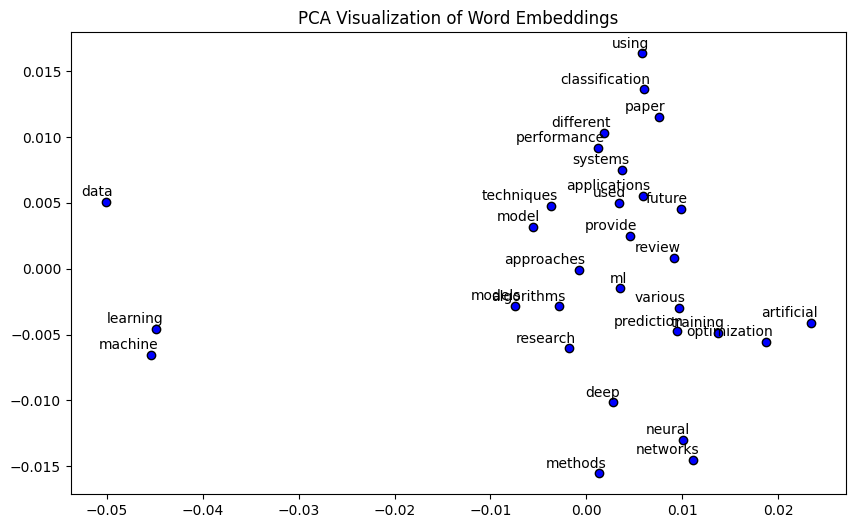


--- Semantic Similarity Analysis ---
Similarity between 'machine' and 'learning': 0.9058
Similarity between 'data' and 'analysis': 0.8057


In [5]:
# Write your code here
!pip install --upgrade gensim

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


# sentences was created in the previous step (list of lists of words)
sentences = [doc.split() for doc in reviews_cleaned]

model = Word2Vec(sentences, vector_size=300, window=5, min_count=1, workers=4)
print("Word2Vec Model Trained Successfully.")

# (2) Visualize the embeddings using PCA
words_to_plot = list(model.wv.index_to_key)[:30]
word_vectors = np.array([model.wv[w] for w in words_to_plot])

pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 6)) ## fig size I have given (10,6) you can try 10,4 I like adjust size based on the graph.
plt.scatter(coords[:, 0], coords[:, 1], edgecolors='k', c='blue') ## I have given color as blue we can give any other color like orange if you want.

for i, word in enumerate(words_to_plot):
    plt.annotate(word, xy=(coords[i, 0], coords[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom')

plt.title("PCA Visualization of Word Embeddings")
plt.show()

# (3) Semantic Similarity Analysis
print("\n--- Semantic Similarity Analysis ---")
def check_sim(w1, w2):
    if w1 in model.wv and w2 in model.wv:
        print(f"Similarity between '{w1}' and '{w2}': {model.wv.similarity(w1, w2):.4f}")

check_sim("machine", "learning")
check_sim("data", "analysis")








## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [ ]:
# The GitHub link of your final csv file
Text classification (sentiment analysis) is an NLP task.

Dataset: One hundred AI/ML research abstracts from Semantic Scholar(The dataset I have used).

Schema for Labeling:

Positive: Abstracts that mentioned words like high accuracy, successful improvements I have given positive.

Technical explanations of methods, surveys, or abstracts that give factual summaries without expressly expressing success or failure are considered neutral.

Negative: Abstracts that mentioned word like loss or failure etc I have given rating as negative like example Doc_70 describes about cancer and loss.

# Link:https://github.com/paidasahithi26/NLP_Assignments02/blob/main/Annotated_scholar_data_final_.csv.%20(1).csv



# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
# Type your answer
## Overall, from my point of view this assignment was really helpful.
## It took me nearly 10 hours to complete the assignment because I am learning them for the first time. learning TF-IDF and Cosine Similarity logic was diificult for me and I really enjoyed Word2Vec visualization is was really a good task I enjoyed creating a scatter plot.